In [ ]:
!pip -q install gdown

In [ ]:
file_id = "1UXoTFjqnXlCW0kg-qz9UNg59c_5PfAS2"
url = f"https://drive.google.com/uc?id={file_id}"
!gdown --fuzzy "$url" -O bifurcation_data.json

Downloading...
From: https://drive.google.com/uc?id=1UXoTFjqnXlCW0kg-qz9UNg59c_5PfAS2
To: /content/bifurcation_data.json
100% 53.3k/53.3k [00:00<00:00, 52.2MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from matplotlib.colors import ListedColormap

from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, precision_recall_curve, auc
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, make_scorer


The data is labelled **1 for has bifurcation** and **0 for no bifurcation**.

If the scan over $\alpha$ contains no valid crossing of $\epsilon$, then we conclude no bifurcation exists in the admissible (finite, normalised) domain.


In [ ]:
data = pd.read_json("bifurcation_data.json")
X = np.asarray(list(data["X"]), dtype=float)
y = np.asarray(list(data["Y"]), dtype=int)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50)

Using RBF with constant kernel
$$
\kappa(x_i, x_j)
= \sigma_f^2 \exp\!\left(
- \frac{d(x_i, x_j)^2}{2\ell^2}
\right)
$$

In [ ]:
kernel = C(1.0) * RBF(length_scale=np.ones(6))
gpc = make_pipeline(
    StandardScaler(),
    GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=20, random_state=0, max_iter_predict=300)
)
gpc.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussianprocessclassifier',
                 GaussianProcessClassifier(kernel=1**2 * RBF(length_scale=[1, 1, 1, 1, 1, 1]),
                                           max_iter_predict=300,
                                           n_restarts_optimizer=20,
                                           random_state=0))])

Observing the RBF length scale reveals that parameters b and f have the lowest values. Bifurcation outcomes vary more with respect to b and f, meaning that bifurcations are more sensitive to change in these parameters within the sampled parameter domain.

In [ ]:
print(gpc.named_steps["gaussianprocessclassifier"].kernel_)
# training accuracy
train_acc = (gpc.predict(X_train) == y_train).mean()
print("train acc:", train_acc)

# probability spread
p_train = gpc.predict_proba(X_train)
print("train p(min,max,mean):", p_train.min(), p_train.max(), p_train.mean())
p_test = gpc.predict_proba(X_test)[:, 1]
print("test p(min,max,mean):", p_test.min(), p_test.max(), p_test.mean())

# testing accuracy
y_pred = gpc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("test acc:", accuracy)


3.91**2 * RBF(length_scale=[2.77, 2.09, 2.83, 8.43, 2.36, 1.11])
train acc: 0.925
train p(min,max,mean): 0.011886732821267287 0.9881132671787327 0.5000000000000001
test p(min,max,mean): 0.022017994538146013 0.9807147490637362 0.5858373337429886
test acc: 0.8166666666666667


In [ ]:
for i in range(6):
    f = X_train[:,i]
    print("f mean y=1:", f[y_train==1].mean(), "std:", f[y_train==1].std())
    print("f mean y=0:", f[y_train==0].mean(), "std:", f[y_train==0].std())

f mean y=1: 0.39521723066070696 std: 0.1876334620375283
f mean y=0: 0.2752061734690869 std: 0.18538171515521243
f mean y=1: 0.04166627177136382 std: 0.024215302115254425
f mean y=0: 0.05198806717407961 std: 0.025255758473132744
f mean y=1: 0.004783248109926723 std: 0.002933297723450861
f mean y=0: 0.005701793686118585 std: 0.0027501181031202387
f mean y=1: 0.022096838835627807 std: 0.014306502146879384
f mean y=0: 0.023754400950559595 std: 0.013916534578874986
f mean y=1: 0.01550226014810564 std: 0.008171260102857934
f mean y=0: 0.011307903047620005 std: 0.007612440796277477
f mean y=1: 0.026593734134486447 std: 0.01757599712589615
f mean y=0: 0.04539395536977497 std: 0.01950950811541335


Confusion matrix on the testing data show that the model is overall returning true values, with it being better at detecting bifurcations than non-bifurcations.

<Axes: title={'center': 'Confusion matrix on bifurcation test data'}>

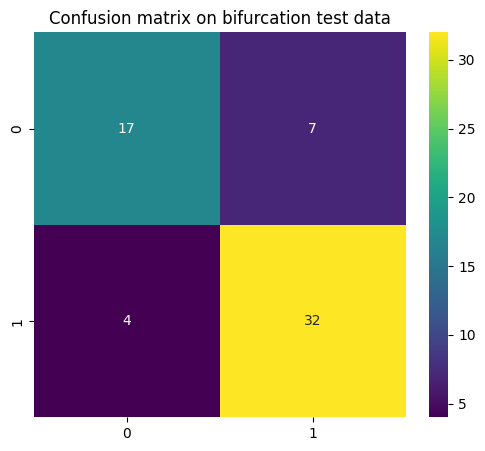

In [ ]:
y_pred = gpc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.title("Confusion matrix on bifurcation test data")
sn.heatmap(cm, cmap="viridis", annot=True)

Precision - class 1: 0.82, class 0: 0.81. The classification report shows that when the model predicts either class, it's usually right around 80% of the time.

Recall - class 1: 0.89, class 0: 0.71. Shows the model is much better at detecting bifurcations than non-bifurcations.

F1-score - drops for class 0 due to lower recall.

Overall this shows that the model is good at detecting bifurcations in our sampled parameter domain, but there are moderate false detections for non-bifurcations.

<Axes: title={'center': 'Classification report on bifurcation test data'}>

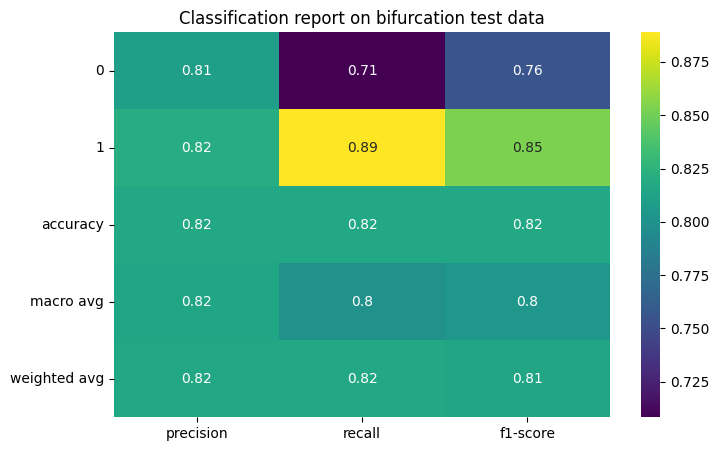

In [ ]:
cr = classification_report(y_test, y_pred, output_dict=True)
df_cr = pd.DataFrame(cr).T
metrics = ["precision", "recall", "f1-score"]
plt.figure(figsize=(8, 5))
plt.title("Classification report on bifurcation test data")
sn.heatmap(df_cr[metrics], cmap="viridis", annot=True)

ROC-AUC and PR-AUC measure ranking quality, meaning how well the model orders points in the parameter space from "least likely" to "most likely" to have bifurcations.

The ROC-AUC value shows that if we randomly choose a parameter vector that produces a bifurcation and one that does not, the model assigns a higher bifurcation probability to the true bifurcation point 93% of the time.

The PR-AUC value shows that the model can recover most bifurcation points while keeping false positives low.


In [ ]:
y_proba = gpc.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_proba))
prec, rec, _ = precision_recall_curve(y_test, y_proba)
print("PR AUC:", auc(rec, prec))

ROC AUC: 0.9259259259259258
PR AUC: 0.9567419511108546


Below is the plot for the permutation importance on the test set. As also suggested by the RBF length scales, parameter f has the greatest impact on the result, indicating that changes in f lead to the largest decrease in model performance when permuted.

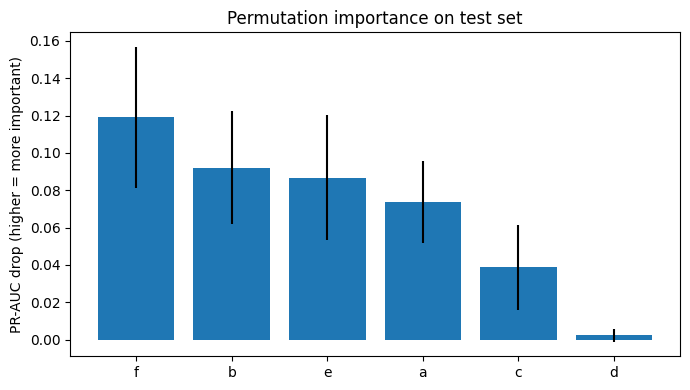

In [ ]:
result = permutation_importance(
    gpc, X_test, y_test,
    scoring="average_precision",
    n_repeats=30,
    random_state=0
)

importances = result.importances_mean
stds = result.importances_std

names = np.array(["a","b","c","d","e","f"])
order = np.argsort(importances)[::-1]

plt.figure(figsize=(7,4))
plt.bar(names[order], importances[order], yerr=stds[order])
plt.ylabel("PR-AUC drop (higher = more important)")
plt.title("Permutation importance on test set")
plt.tight_layout()
plt.show()

Below is the KDE pairplot of the data without the model for all parameter pairs. While most of the data largely overlaps, f tends to show the greatest separation within the dataset, further suggesting it has the strongest influence on distinguishing between bifurcation and non-bifurcation cases.

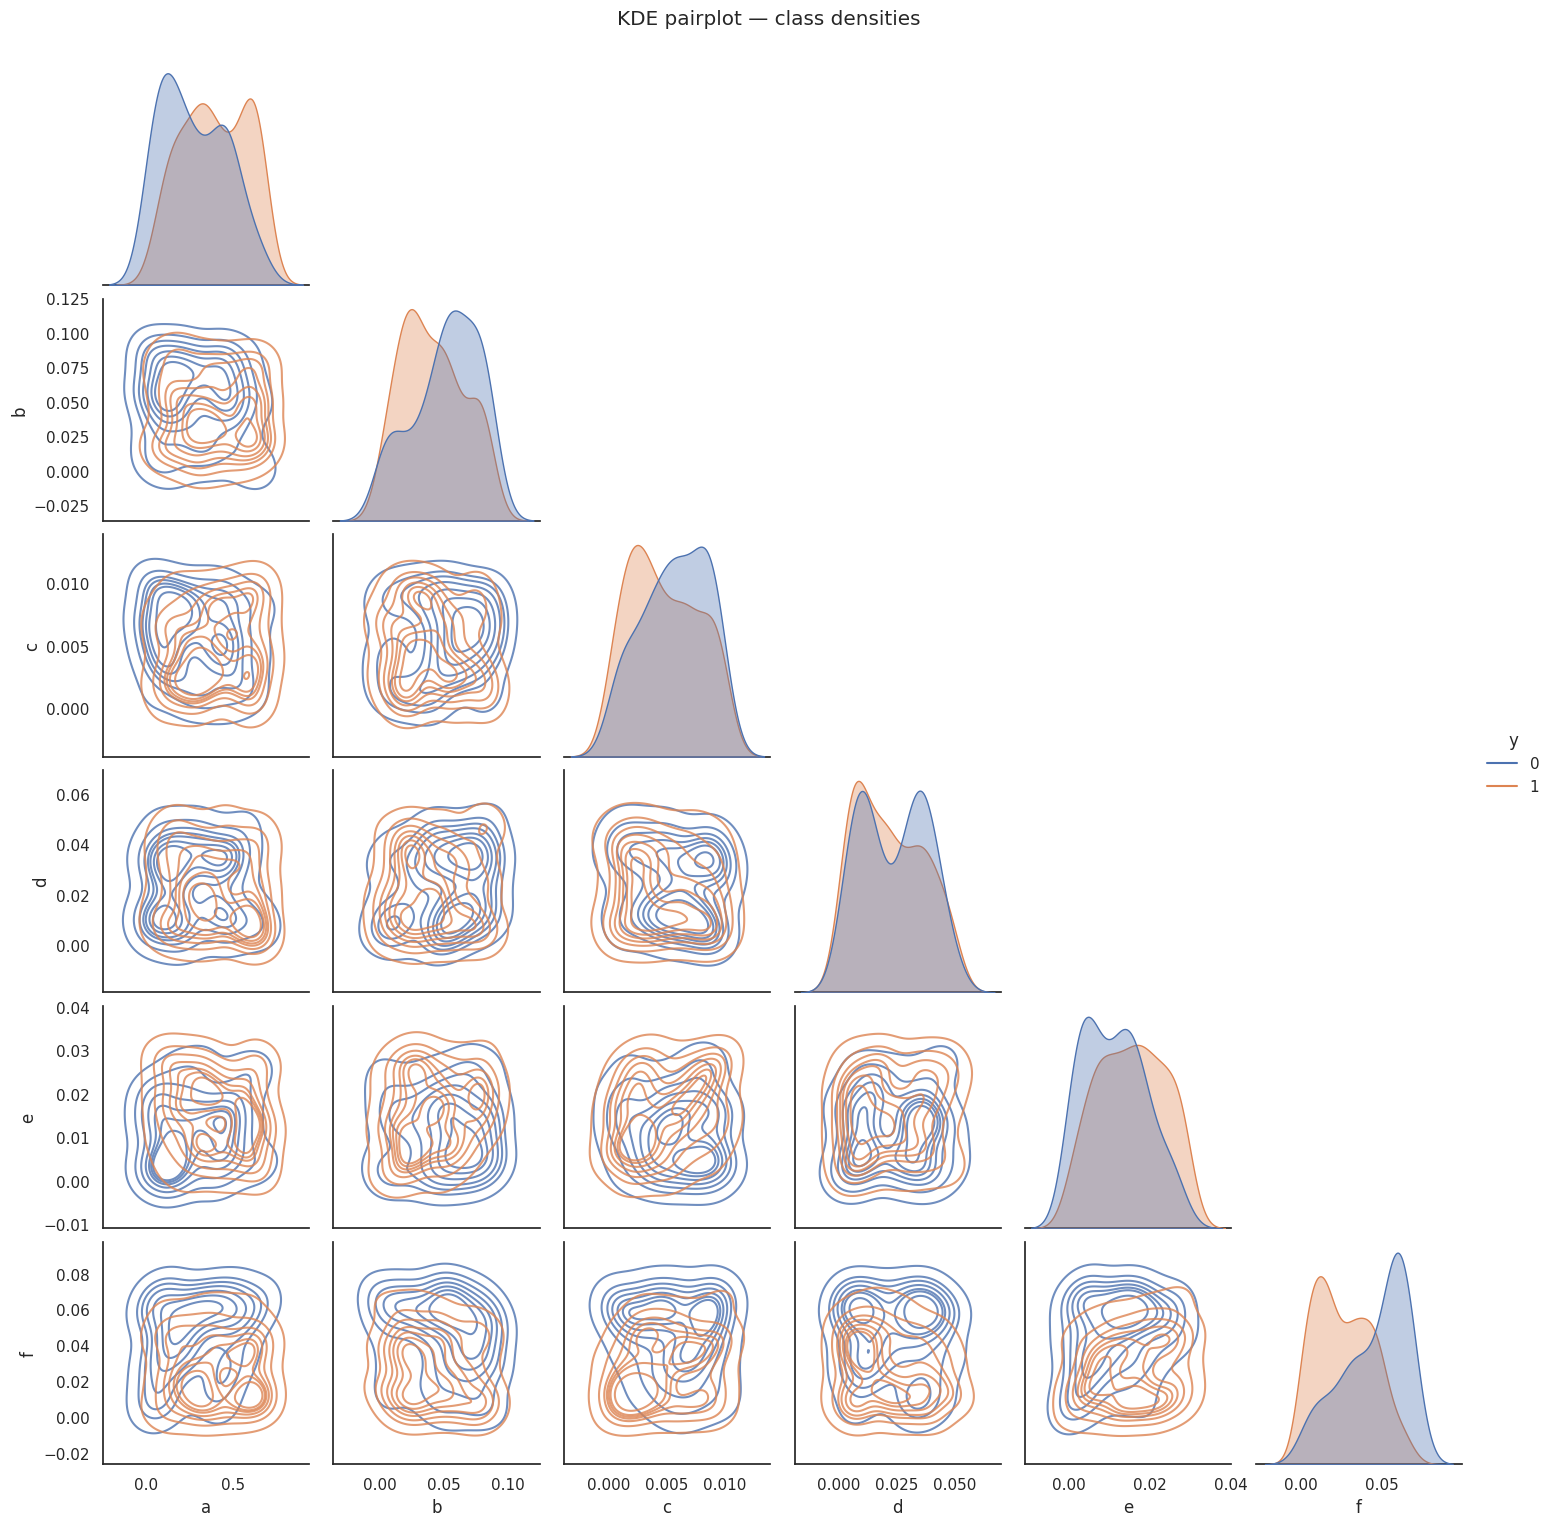

In [ ]:
cols = ["a", "b", "c", "d", "e", "f"]
df = pd.DataFrame(X_train, columns=cols)
df["y"] = y_train

sn.set(style="white", context="notebook")

g = sn.pairplot(
    df,
    vars=cols,
    hue="y",
    kind="kde",
    diag_kind="kde",
    corner=True,
    plot_kws=dict(levels=8, thresh=0.05, common_norm=False, alpha=0.8),
    diag_kws=dict(fill=True, common_norm=False, alpha=0.35)
)

g.fig.suptitle("KDE pairplot — class densities", y=1.02)
plt.show()

In [ ]:
def plotHeatMap(ax, i, j, X, y, gpc, grid_n=250, levels=60, show_points=True):

    params = ["a", "b", "c", "d", "e", "f"]

    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    filler = X.mean(axis=0)

    xi = X[:, i]
    xj = X[:, j]

    i_min, i_max = xi.min(), xi.max()
    j_min, j_max = xj.min(), xj.max()

    pad_i = 0.05 * (i_max - i_min + 1e-12)
    pad_j = 0.05 * (j_max - j_min + 1e-12)

    grid_i = np.linspace(max(0.0, i_min - pad_i), min(1.0, i_max + pad_i), grid_n)
    grid_j = np.linspace(max(0.0, j_min - pad_j), min(1.0, j_max + pad_j), grid_n)

    I, J = np.meshgrid(grid_i, grid_j)

    X_grid = np.tile(filler, (I.size, 1))
    X_grid[:, i] = I.ravel()
    X_grid[:, j] = J.ravel()

    P = gpc.predict_proba(X_grid)[:, 1].reshape(I.shape)

    hm = ax.contourf(I, J, P, levels=np.linspace(0, 1, levels))
    ax.contour(I, J, P, levels=[0.5], linewidths=2)

    if show_points:
        ax.scatter(X[y == 0, i], X[y == 0, j], s=18, label="y=0")
        ax.scatter(X[y == 1, i], X[y == 1, j], s=18, label="y=1")

    ax.set_xlabel(f"{params[i]}")
    ax.set_ylabel(f"{params[j]}")
    ax.set_title(f"({params[i]}, {params[j]}) with others = mean")

    return hm

In [ ]:
def plot_all_pairs_heatmaps(X_ref, y_ref, gpc, grid_n=200, levels=50, show_points=False):
    pairs = [(i, j) for i in range(6) for j in range(i+1, 6)]
    nplots = len(pairs)

    nrows, ncols = 3, 5
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.8*nrows), constrained_layout=True)
    axes = axes.ravel()

    hms = []
    for ax, (i, j) in zip(axes, pairs):
        hm = plotHeatMap(
            ax=ax,
            i=i,
            j=j,
            X_ref=X_ref,
            y_ref=y_ref,
            gpc=gpc,
            grid_n=grid_n,
            levels=levels,
            show_points=show_points
        )
        hms.append(hm)

    cbar = fig.colorbar(hms[-1], ax=axes[:nplots], fraction=0.02, pad=0.02)
    cbar.set_label("Predicted P(y=1 | x)")

    fig.suptitle(f"GPC probability heatmaps for all (i,j) pairs — others filled with mean", y=1.02)
    plt.show()

Below shows the heatmaps of the predicted probabilities of bifurcations for parameter pairs, while the remaining parameters are set to the dataset mean. Visually, plots of pairs including f tend to show a larger region of likely non-bifurcation, which further supports that the value of f has a strong impact on whether bifurcations occur. Across most parameter pairs, the plotted data points tend to overlap, and within these regions the model mostly predicts a bifurcation being present, which explains the moderate false detections for non-bifurcations. It is important to note that the other parameter values are fixed at the mean, so each heatmap represents only a 2D slice through a highly nonlinear 6D space; as a result, the observed bifurcation regions may not reflect the true global behaviour and can obscure important parameter interactions.

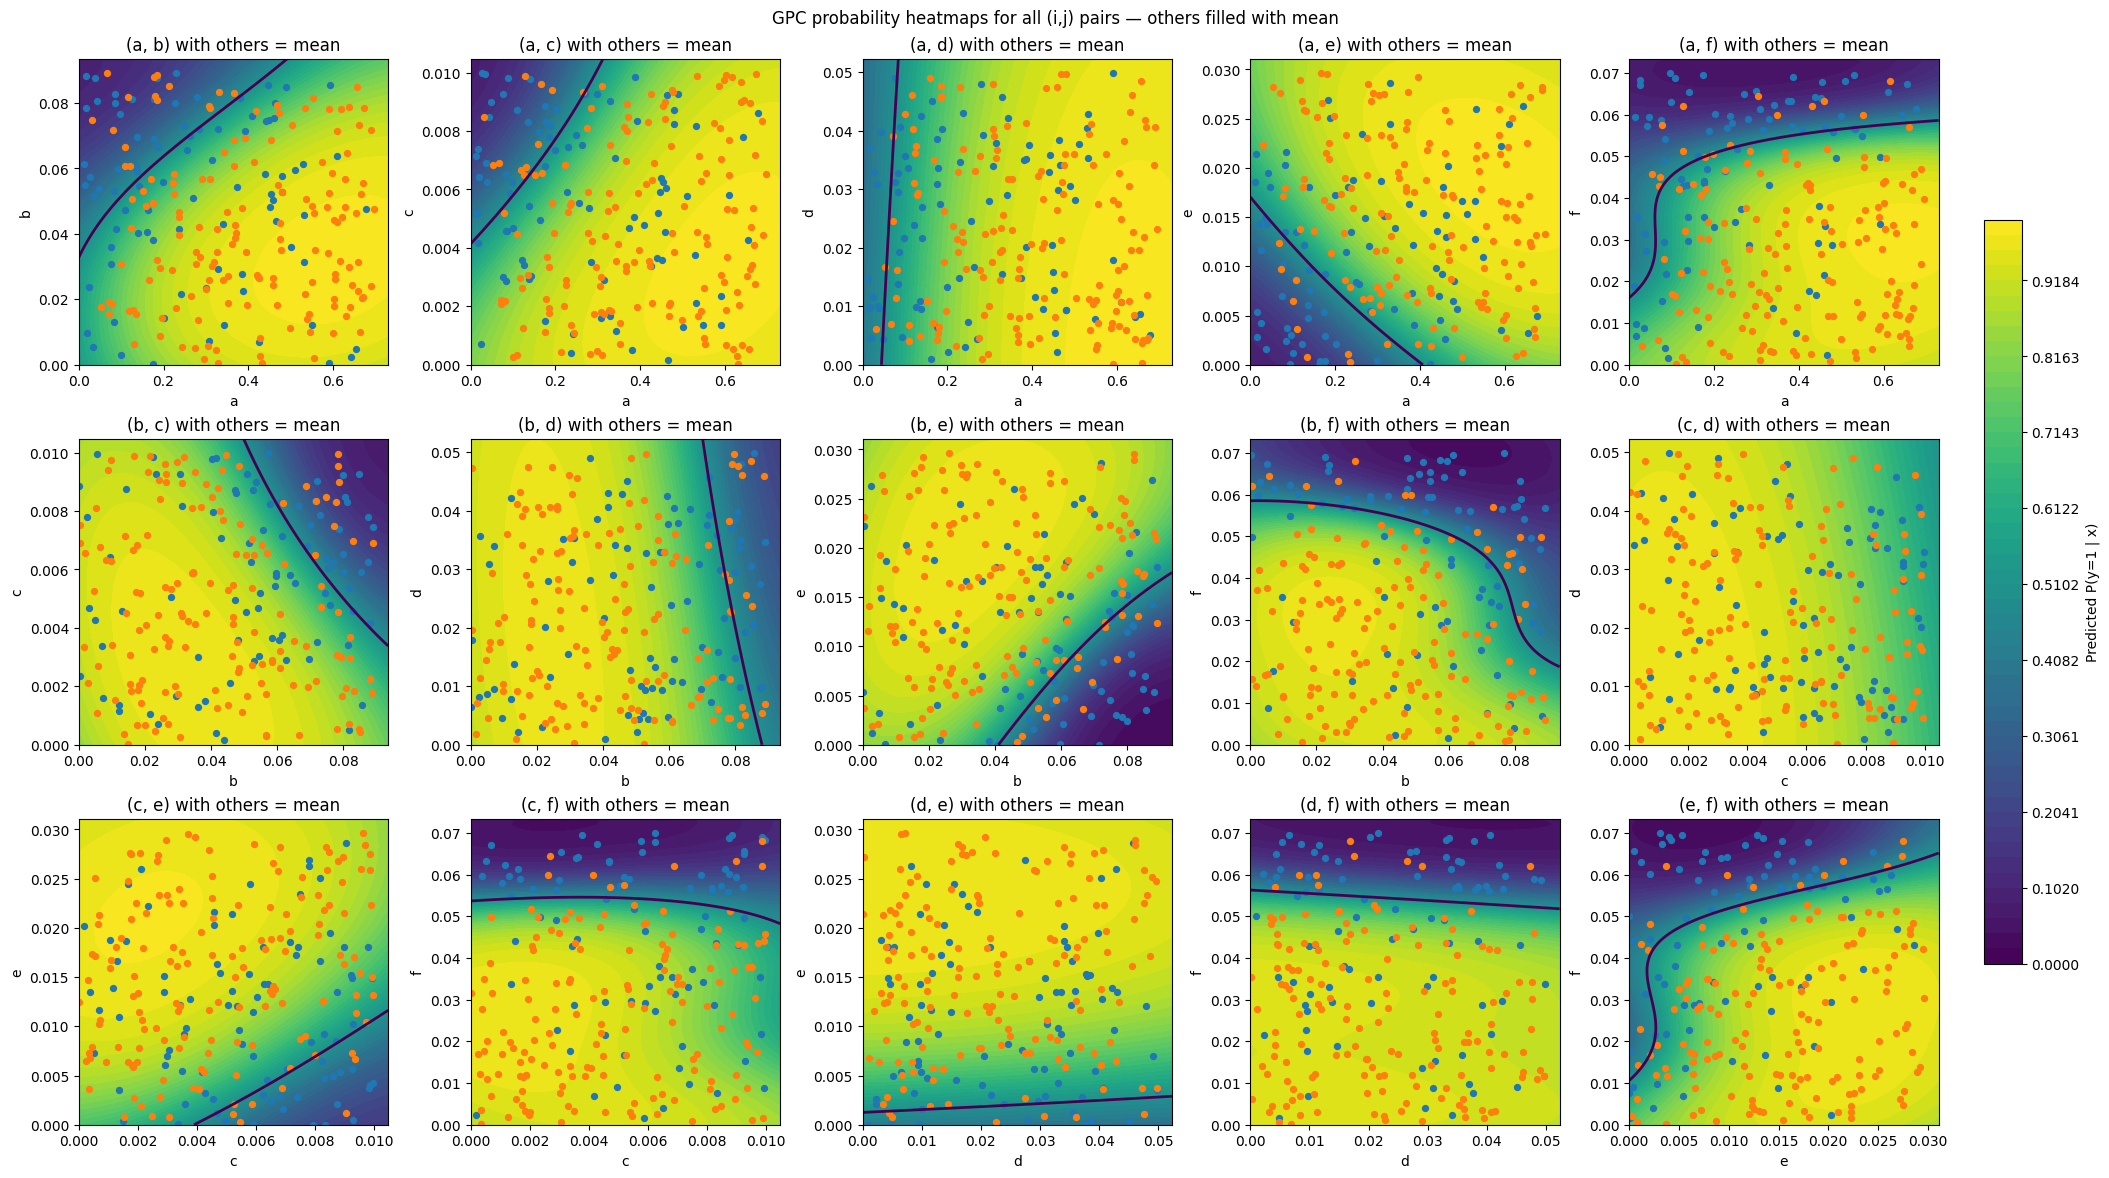

In [ ]:
plot_all_pairs_heatmaps(X_train, y_train, gpc, grid_n=200, levels=50, show_points=True)

The PCA plots for the first two components are shown for both the training and testing sets. In both cases, there is some visible separation between the bifurcation and non-bifurcation classes, although there is still a noticeable overlap between the two. This suggests that while the main variation in the data captures some of the structure related to bifurcations, the classes are not fully separable in just two dimensions. The similarity between the training and testing plots also indicates that the model is not overfitting and that the underlying structure is consistent across both datasets.

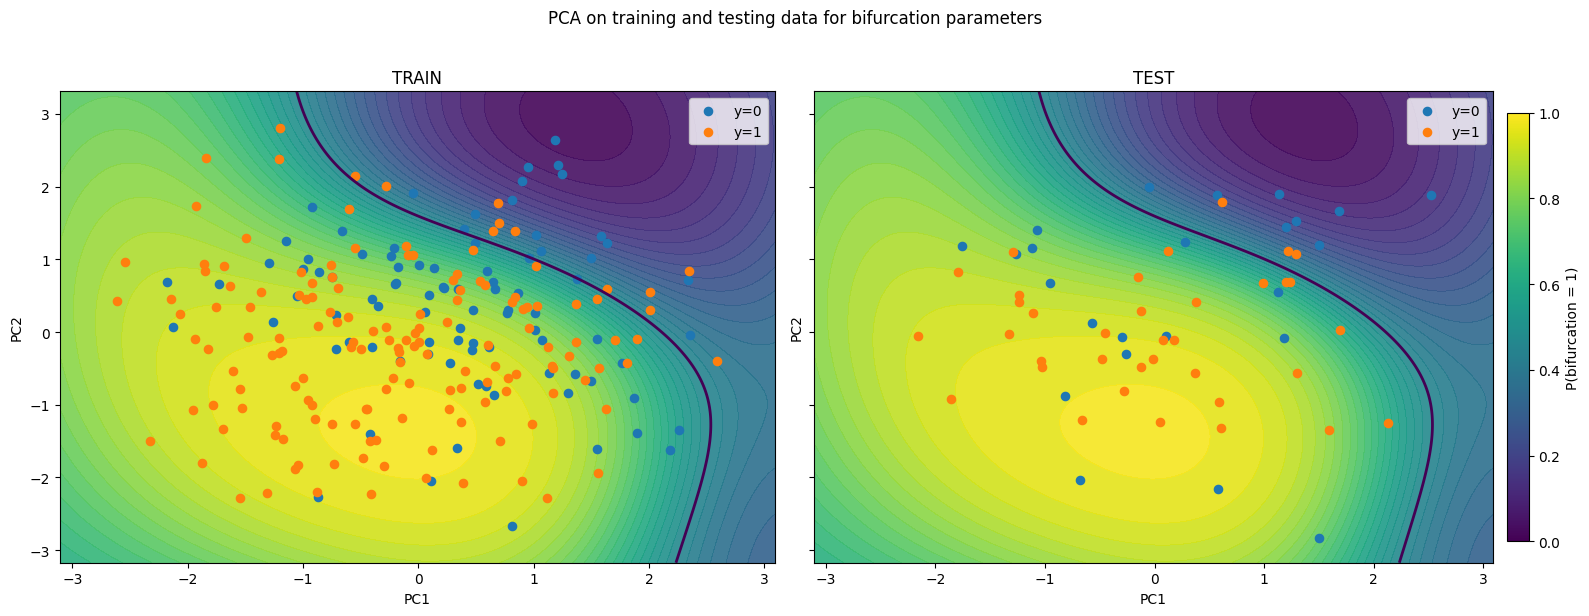

In [ ]:
pca_pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=0)
)

Xtr_2 = pca_pipe.fit_transform(X_train)
Xte_2 = pca_pipe.transform(X_test)

pad = 0.5
x_min, x_max = Xtr_2[:, 0].min() - pad, Xtr_2[:, 0].max() + pad
y_min, y_max = Xtr_2[:, 1].min() - pad, Xtr_2[:, 1].max() + pad

grid_n = 250
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_n),
                     np.linspace(y_min, y_max, grid_n))
grid_2d = np.c_[xx.ravel(), yy.ravel()]

grid_6d = pca_pipe.inverse_transform(grid_2d)

proba = gpc.predict_proba(grid_6d)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

hm = None

def plot_split(ax, points_2d, labels, title):

    hm = ax.contourf(xx, yy, proba, levels=40, alpha=0.9)

    ax.contour(xx, yy, proba, levels=[0.5], linewidths=2)

    ax.scatter(points_2d[labels == 0, 0], points_2d[labels == 0, 1], s=35, label="y=0")
    ax.scatter(points_2d[labels == 1, 0], points_2d[labels == 1, 1], s=35, label="y=1")

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

plot_split(axes[0], Xtr_2, y_train, "TRAIN")
plot_split(axes[1], Xte_2, y_test,  "TEST")

cbar = fig.colorbar(hm, ax=axes[1], fraction=0.03, pad=0.02)
cbar.set_label("P(bifurcation = 1)")
fig.suptitle(f"PCA on training and testing data for bifurcation parameters", y=1.02)
plt.tight_layout()
plt.show()